In [28]:
import rioxarray
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

xr.set_options(keep_attrs=True, display_expand_data=False)

### exercise 1 
- load data
- inspect it - i.e., print its dimensions, coordinates& attributess
- print crs & affine info

find data in the data folder


In [44]:
#load data
#url='data/Libya-2023-09-13.tif'
url='data/input_raster.tif'
#url='data/landsat7.tif'
#url='mosaic.tif'
data=rioxarray.open_rasterio(url)
data

<xarray.DataArray (band: 7, y: 522, x: 514)> Size: 8MB
[1878156 values with dtype=float32]
Coordinates:
  * band         (band) int64 56B 1 2 3 4 5 6 7
  * x            (x) float64 4kB 6.447e+05 6.448e+05 ... 6.908e+05 6.909e+05
  * y            (y) float64 4kB 4.026e+06 4.026e+06 ... 3.979e+06 3.979e+06
    spatial_ref  int64 8B 0
Attributes: (12/96)
    ALGORITHM_SOURCE_SURFACE_REFLECTANCE:  LaSRC_1.6.0
    ALGORITHM_SOURCE_SURFACE_TEMPERATURE:  st_1.5.0
    AREA_OR_POINT:                         Area
    CLOUD_COVER:                           0
    CLOUD_COVER_LAND:                      0
    COLLECTION_CATEGORY:                   T1
    ...                                    ...
    WRS_PATH:                              39
    WRS_ROW:                               35
    WRS_TYPE:                              2
    _FillValue:                            -inf
    scale_factor:                          1.0
    add_offset:                            0.0

In [45]:
#check metadata
print(data)

<xarray.DataArray (band: 7, y: 522, x: 514)> Size: 8MB
[1878156 values with dtype=float32]
Coordinates:
  * band         (band) int64 56B 1 2 3 4 5 6 7
  * x            (x) float64 4kB 6.447e+05 6.448e+05 ... 6.908e+05 6.909e+05
  * y            (y) float64 4kB 4.026e+06 4.026e+06 ... 3.979e+06 3.979e+06
    spatial_ref  int64 8B 0
Attributes: (12/96)
    ALGORITHM_SOURCE_SURFACE_REFLECTANCE:  LaSRC_1.6.0
    ALGORITHM_SOURCE_SURFACE_TEMPERATURE:  st_1.5.0
    AREA_OR_POINT:                         Area
    CLOUD_COVER:                           0
    CLOUD_COVER_LAND:                      0
    COLLECTION_CATEGORY:                   T1
    ...                                    ...
    WRS_PATH:                              39
    WRS_ROW:                               35
    WRS_TYPE:                              2
    _FillValue:                            -inf
    scale_factor:                          1.0
    add_offset:                            0.0


In [46]:
#inspect data
data.dims

('band', 'y', 'x')

In [47]:
data.coords

Coordinates:
  * band         (band) int64 56B 1 2 3 4 5 6 7
  * x            (x) float64 4kB 6.447e+05 6.448e+05 ... 6.908e+05 6.909e+05
  * y            (y) float64 4kB 4.026e+06 4.026e+06 ... 3.979e+06 3.979e+06
    spatial_ref  int64 8B 0

In [48]:
data.rio.crs

CRS.from_epsg(32611)

In [49]:
data.rio.transform()

Affine(90.0, 0.0, 644670.0,
       0.0, -90.0, 4025880.0)

### exercise 2
- reproject to new crs - wgs84
- print crs & check dimensions & coordinates of the projected data
- plot original and reprojected datasets for comparison


In [50]:
#reproject to WGS84
reprojected_data=data.rio.reproject('EPSG:4326')
print(reprojected_data.rio.crs)

EPSG:4326


In [51]:
#check dimensions
reprojected_data.dims

('band', 'y', 'x')

In [52]:
#check coordinates
reprojected_data.coords

Coordinates:
  * x            (x) float64 5kB -115.4 -115.4 -115.4 ... -114.9 -114.9 -114.9
  * y            (y) float64 4kB 36.37 36.37 36.36 36.36 ... 35.94 35.94 35.94
  * band         (band) int64 56B 1 2 3 4 5 6 7
    spatial_ref  int64 8B 0

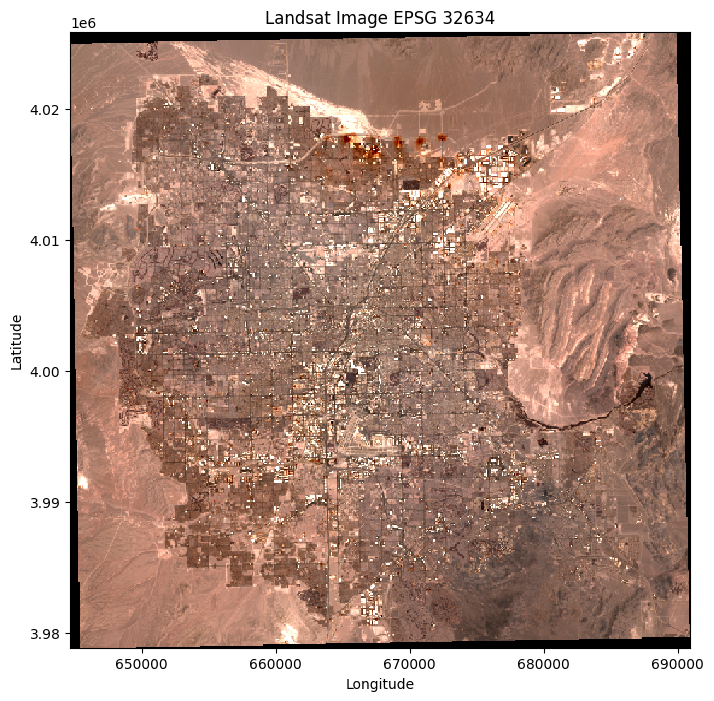

In [53]:
#plot original dataset(epsg 32634)
plt.figure(figsize=(8, 8))
data.sel(band=[3,2,1]).plot.imshow(vmin=0, vmax=0.3)
plt.title("Landsat Image EPSG 32634")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

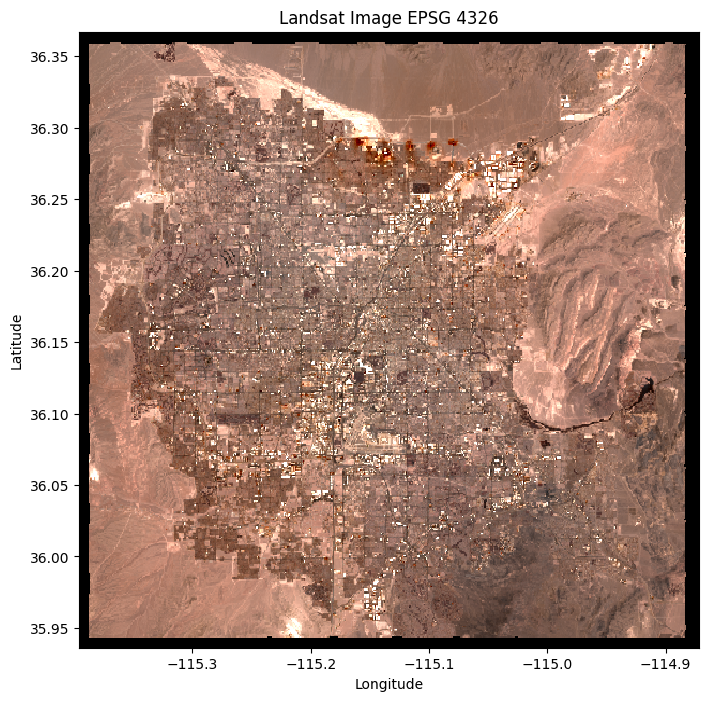

In [54]:
#plot reprojected dataset(epsg 4326)
plt.figure(figsize=(8, 8))
reprojected_data.sel(band=[3, 2, 1]).plot.imshow(vmin=0, vmax=0.3)
plt.title("Landsat Image EPSG 4326")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

### resample the raster to a different resolution & compute NDWI
- using an average resampling method, resamle the data to 500m resolution
- check the new dimensions after resampling
- compute NDWI
- save resampled dataset as a geotiff


In [55]:
#check available bands
print(data['band'])

<xarray.DataArray 'band' (band: 7)> Size: 56B
1 2 3 4 5 6 7
Coordinates:
  * band         (band) int64 56B 1 2 3 4 5 6 7
    spatial_ref  int64 8B 0


In [56]:
resampled_data=reprojected_data.rio.reproject(reprojected_data.rio.crs, resolution=(1000,1000))

In [57]:
resampled_data.shape

(7, 1, 1)

### compute NDWI
NDWI is calculated as:
- NDWI=(GREEN-NIR)/(GREEN+NIR)
- NDWI=(B3-B5)/(B3+B5)

In [70]:
#select the bands of use
green_band=reprojected_data.sel(band=3)
nir_band=reprojected_data.sel(band=5)

#calculate NDWI
ndwi=(green_band-nir_band)/(green_band+nir_band)
ndwi=ndwi.clip(min=-1, max=1) #clip values to the range -1 to 1
ndwi.attrs['long_name']='NDWI'


### plot NDWI using Matplotlib

<function matplotlib.pyplot.show(close=None, block=None)>

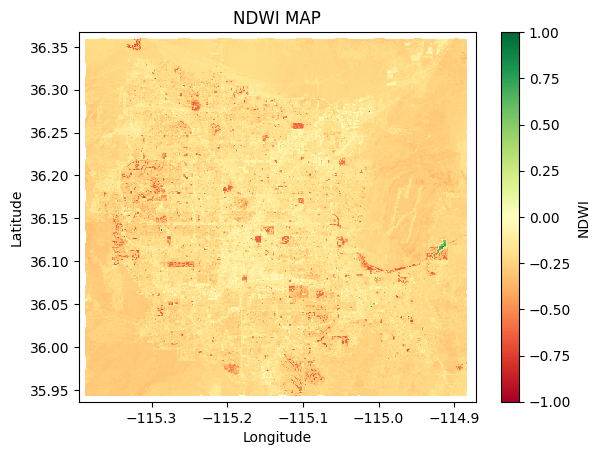

In [71]:
ndwi.plot(cmap='RdYlGn', vmin=-1, vmax=+1)
plt.title('NDWI MAP')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show

### Mask out areas with invalid NDWI values (e.g., urban areas) by appying a threshold

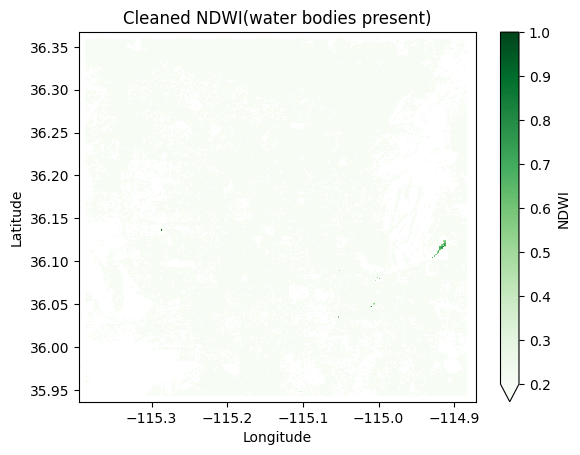

In [73]:
#mask out urban areas (NDWI)
clean_ndwi=ndwi.where(ndwi>-0.25)
clean_ndwi.plot(cmap='Greens', vmin=0.2, vmax=1)
plt.title("Cleaned NDWI(water bodies present)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()